# Week 4 Assignment: GCNs & Spectral Graph Theory
**Notebook contents:** Q2 (GCN layer in NumPy), Q3.2 (eigenvalue numerical check), Q4 (over-smoothing on Cora with PyTorch Geometric)

> Written proofs / conceptual answers for Q1, Q3.1, Q3.3, Q4.4 are in a separate `Answers.md` (not in this notebook).

## Q2. Implementing One GCN Layer (NumPy)

In [1]:
import numpy as np

def build_normalized_adj(A):
    """Given adjacency matrix A (no self-loops), return the renormalized
    symmetric adjacency A_hat = D_tilde^{-1/2} A_tilde D_tilde^{-1/2}."""
    N = A.shape[0]
    A_tilde = A + np.eye(N)
    D_tilde = np.diag(A_tilde.sum(axis=1))
    D_tilde_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D_tilde)))
    A_hat = D_tilde_inv_sqrt @ A_tilde @ D_tilde_inv_sqrt
    return A_hat

def gcn_layer(A_hat, X, W):
    """One GCN layer: H = ReLU(A_hat @ X @ W)"""
    return np.maximum(0, A_hat @ X @ W)

# ---- Graph from Q1: 3-node path, Node1 - Node2 - Node3 ----
A = np.array([[0, 1, 0],
              [1, 0, 1],
              [0, 1, 0]], dtype=float)

A_hat = build_normalized_adj(A)
print("A_hat:\n", np.round(A_hat, 4))


A_hat:
 [[0.5    0.4082 0.    ]
 [0.4082 0.3333 0.4082]
 [0.     0.4082 0.5   ]]


In [2]:
# Random feature matrix X (N=3 nodes, F=4 input features) and weight matrix W (F=4 -> F'=2)
np.random.seed(0)
X = np.random.randn(3, 4)
W = np.random.randn(4, 2)

H = gcn_layer(A_hat, X, W)
print("Input X:\n", np.round(X, 4))
print("\nWeight W:\n", np.round(W, 4))
print("\nOutput H = ReLU(A_hat X W):\n", np.round(H, 4))


Input X:
 [[ 1.7641  0.4002  0.9787  2.2409]
 [ 1.8676 -0.9773  0.9501 -0.1514]
 [-0.1032  0.4106  0.144   1.4543]]

Weight W:
 [[ 0.761   0.1217]
 [ 0.4439  0.3337]
 [ 1.4941 -0.2052]
 [ 0.3131 -0.8541]]

Output H = ReLU(A_hat X W):
 [[2.8053 0.    ]
 [2.6066 0.    ]
 [1.3504 0.    ]]


**Quick check answer (N >> F):** compute `A_hat @ (X @ W)` first, i.e. transform features before aggregating.
See `Answers.md` Q2.2 for the full reasoning (FLOP-count comparison).

## Q3.2 Numerical Check — Eigenvalues on Karate Club Graph

In [3]:
import networkx as nx

G = nx.karate_club_graph()
A_k = nx.to_numpy_array(G)
N = A_k.shape[0]
I_N = np.eye(N)

# ---- Version 1: I_N + D^{-1/2} A D^{-1/2}  (paper's original, pre-renormalization-trick form) ----
D_k = np.diag(A_k.sum(axis=1))
D_k_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D_k)))
sym_norm = D_k_inv_sqrt @ A_k @ D_k_inv_sqrt
mat_original = I_N + sym_norm

# ---- Version 2: renormalized  D_tilde^{-1/2} A_tilde D_tilde^{-1/2}  (self-loop added BEFORE normalizing) ----
A_hat_k = build_normalized_adj(A_k)

eig_original = np.linalg.eigvalsh(mat_original)
eig_renorm   = np.linalg.eigvalsh(A_hat_k)

print(f"I_N + D^(-1/2) A D^(-1/2)   -> eigenvalue range: [{eig_original.min():.4f}, {eig_original.max():.4f}]")
print(f"Renormalized A_hat          -> eigenvalue range: [{eig_renorm.min():.4f}, {eig_renorm.max():.4f}]")


I_N + D^(-1/2) A D^(-1/2)   -> eigenvalue range: [0.3078, 2.0000]
Renormalized A_hat          -> eigenvalue range: [-0.5819, 1.0000]


**Observation:** the original `I + D^-1/2 A D^-1/2` has its top eigenvalue sitting near **2** (matches the `[0,2]` bound
from Q3.1, since this matrix is `2I - L`). The renormalized version's top eigenvalue is capped exactly at **1**
(it is similarity-equivalent to a row-stochastic matrix, so by Perron–Frobenius λ_max = 1). The bottom eigenvalue of
the renormalized matrix is not tightly 0 for every graph (Karate Club isn't bipartite-free of near-bipartite
substructure, so a few eigenvalues are slightly negative) — but crucially, the largest eigenvalue no longer
approaches 2. That is the property that matters for deep stacking: repeatedly multiplying by a matrix with
λ_max ≈ 2 blows activations up geometrically (`2^K`), while λ_max = 1 does not. Full discussion in `Answers.md` Q3.2.

## Q4. Over-Smoothing in Deep GCNs (Cora, PyTorch Geometric)

In [4]:
# Run this cell FIRST in Colab (only needed once per runtime).
# Colab already ships with a matching torch build, so this installs quickly.
!pip install -q torch_geometric


In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0].to(device)

print(data)
print("Num classes:", dataset.num_classes)


d:\mystuff\GNN_SoC\Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...
Done!


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Num classes: 7


In [6]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        if num_layers == 1:
            self.convs.append(GCNConv(in_channels, out_channels))
        else:
            self.convs.append(GCNConv(in_channels, hidden_channels))
            for _ in range(num_layers - 2):
                self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.convs.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=0.5, training=self.training)
        return x


In [7]:
def train_and_eval(num_layers, epochs=200, hidden=16, lr=0.01, weight_decay=5e-4):
    model = GCN(dataset.num_features, hidden, dataset.num_classes, num_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index).argmax(dim=1)
        correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
        acc = int(correct) / int(data.test_mask.sum())
    return acc

Ks = [2, 4, 8, 16]
accuracies = []
for k in Ks:
    acc = train_and_eval(k)
    accuracies.append(acc)
    print(f"K={k:2d} layers -> test accuracy: {acc:.4f}")


K= 2 layers -> test accuracy: 0.8090
K= 4 layers -> test accuracy: 0.7450
K= 8 layers -> test accuracy: 0.6510
K=16 layers -> test accuracy: 0.1350


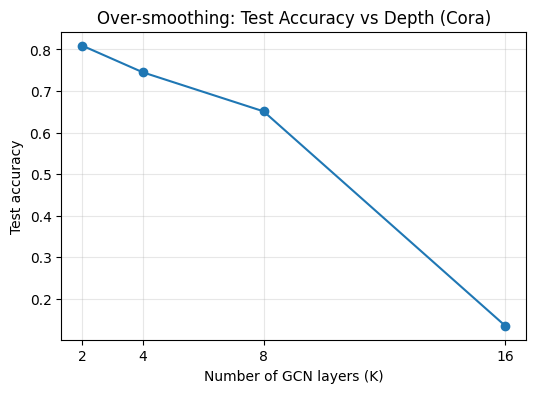

In [8]:
plt.figure(figsize=(6,4))
plt.plot(Ks, accuracies, marker='o')
plt.xlabel("Number of GCN layers (K)")
plt.ylabel("Test accuracy")
plt.title("Over-smoothing: Test Accuracy vs Depth (Cora)")
plt.xticks(Ks)
plt.grid(True, alpha=0.3)
plt.savefig("oversmoothing_plot.png", dpi=150, bbox_inches="tight")
plt.show()


**Conceptual answer (Q4.4):** see `Answers.md` Q4.4 — each layer is a low-pass averaging/smoothing operation over
the graph; stacking many of them repeatedly mixes every node's features with an ever-larger neighborhood until,
after enough layers, all (connected) nodes converge toward the same value, making classes indistinguishable.